# 从预测到决策：有限预算下的序贯筛选

## Goal

在一个确定性虚拟候选池中比较随机选择、预测均值贪心和不确定性感知 UCB。评价对象是固定查询预算下的 best-so-far 轨迹，而不是一次静态测试分数。

对应正文：[第 5 章：从预测到决策与发现](../../docs/part1-ai-foundations/chapter5.md)。

## Setup

### Key Assumptions

- 候选池和真实目标在实验开始前固定，但算法只能查询被选择候选的标签；
- 三种策略使用相同初始样本、预算和随机种子；
- UCB 分数为预测均值加探索系数乘标准差，仅是一个教学策略；
- 结果只适用于当前目标函数、模型、候选池和预算，不说明某策略普遍最优。

In [1]:
from time import perf_counter
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

BASE_SEED = 20260810
N_CANDIDATES = 240
INITIAL_SAMPLES = 6
QUERY_BUDGET = 20
N_REPEATS = 12

print({
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__,
    "base_seed": BASE_SEED,
})

{'python': '3.12.2', 'numpy': '2.4.0', 'scikit_learn': '1.8.0', 'base_seed': 20260810}


## Steps

### 1. Build a virtual candidate pool

In [2]:
pool_rng = np.random.default_rng(BASE_SEED)
candidates = pool_rng.uniform(-2.5, 2.5, size=(N_CANDIDATES, 2))

def virtual_objective(points):
    x_1 = points[:, 0]
    x_2 = points[:, 1]
    broad_peak = 1.8 * np.exp(-0.7 * ((x_1 - 0.9) ** 2 + (x_2 + 0.6) ** 2))
    narrow_peak = 2.6 * np.exp(-2.8 * ((x_1 + 1.2) ** 2 + (x_2 - 1.0) ** 2))
    background = 0.25 * np.sin(2.2 * x_1) * np.cos(1.7 * x_2)
    return broad_peak + narrow_peak + background

true_values = virtual_objective(candidates)
global_best = float(true_values.max())
print({"candidates": len(candidates), "hidden_global_best": round(global_best, 4)})

{'candidates': 240, 'hidden_global_best': 2.5799}


### 2. Define equal-budget strategies

In [3]:
kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1e-6)

def make_model():
    return GaussianProcessRegressor(
        kernel=kernel,
        optimizer=None,
        normalize_y=True,
        random_state=BASE_SEED,
    )

def run_strategy(strategy, seed):
    rng = np.random.default_rng(seed)
    selected = list(rng.choice(N_CANDIDATES, size=INITIAL_SAMPLES, replace=False))
    best_history = [float(true_values[selected].max())]
    trace_rows = [
        {
            "phase": "initial",
            "query_step": 0,
            "candidate_id": int(candidate_id),
            "predicted_mean": np.nan,
            "predicted_std": np.nan,
            "acquisition": np.nan,
            "feedback": float(true_values[candidate_id]),
            "elapsed_seconds": 0.0,
            "failure_status": "ok",
        }
        for candidate_id in selected
    ]

    for query_step in range(1, QUERY_BUDGET + 1):
        step_start = perf_counter()
        available = np.setdiff1d(np.arange(N_CANDIDATES), selected, assume_unique=False)

        if strategy == "random":
            next_index = int(rng.choice(available))
            selected_mean = np.nan
            selected_std = np.nan
            selected_acquisition = np.nan
        else:
            model = make_model()
            model.fit(candidates[selected], true_values[selected])
            mean, std = model.predict(candidates[available], return_std=True)
            if strategy == "greedy":
                acquisition = mean
            elif strategy == "ucb":
                acquisition = mean + 1.5 * std
            else:
                raise ValueError(f"unknown strategy: {strategy}")
            best_available_position = int(np.argmax(acquisition))
            next_index = int(available[best_available_position])
            selected_mean = float(mean[best_available_position])
            selected_std = float(std[best_available_position])
            selected_acquisition = float(acquisition[best_available_position])

        selected.append(next_index)
        best_history.append(float(true_values[selected].max()))
        trace_rows.append(
            {
                "phase": "query",
                "query_step": query_step,
                "candidate_id": next_index,
                "predicted_mean": selected_mean,
                "predicted_std": selected_std,
                "acquisition": selected_acquisition,
                "feedback": float(true_values[next_index]),
                "elapsed_seconds": perf_counter() - step_start,
                "failure_status": "ok",
            }
        )

    assert len(selected) == len(set(selected))
    assert len(selected) == INITIAL_SAMPLES + QUERY_BUDGET
    assert np.all(np.diff(best_history) >= -1e-12)
    return np.array(best_history), np.array(selected), pd.DataFrame(trace_rows)

### 3. Repeat strategies under matched initial conditions

In [4]:
strategy_names = ["random", "greedy", "ucb"]
histories = {strategy: [] for strategy in strategy_names}
trace_frames = []

for repeat in range(N_REPEATS):
    matched_seed = BASE_SEED + repeat
    for strategy in strategy_names:
        history, _, trace = run_strategy(strategy, matched_seed)
        histories[strategy].append(history)
        trace.insert(0, "seed", matched_seed)
        trace.insert(0, "repeat", repeat)
        trace.insert(0, "strategy", strategy)
        trace_frames.append(trace)

histories = {name: np.vstack(values) for name, values in histories.items()}
decision_trace = pd.concat(trace_frames, ignore_index=True)
summary_rows = []
for strategy, values in histories.items():
    final_values = values[:, -1]
    summary_rows.append(
        {
            "strategy": strategy,
            "mean_final_best": final_values.mean(),
            "median_final_best": np.median(final_values),
            "success_within_95pct_of_pool_best": np.mean(final_values >= 0.95 * global_best),
        }
    )
summary = pd.DataFrame(summary_rows)
summary.round(3)

,strategy,mean_final_best,median_final_best,success_within_95pct_of_pool_best
0,random,1.818,1.789,0.167
1,greedy,2.070,1.900,0.250
2,ucb,2.055,1.900,0.167


### 4. Inspect the auditable decision ledger

In [5]:
trace_columns = [
    "strategy", "repeat", "seed", "phase", "query_step", "candidate_id",
    "predicted_mean", "predicted_std", "acquisition", "feedback",
    "elapsed_seconds", "failure_status",
]
decision_trace[trace_columns].head(12)

,strategy,repeat,seed,phase,query_step,candidate_id,predicted_mean,predicted_std,acquisition,feedback,elapsed_seconds,failure_status
0,random,0,20260810,initial,0,39,NaN,NaN,NaN,0.017911,0.000000,ok
1,random,0,20260810,initial,0,155,NaN,NaN,NaN,0.133765,0.000000,ok
2,random,0,20260810,initial,0,166,NaN,NaN,NaN,0.117402,0.000000,ok
3,random,0,20260810,initial,0,209,NaN,NaN,NaN,0.267278,0.000000,ok
4,random,0,20260810,initial,0,210,NaN,NaN,NaN,0.224980,0.000000,ok
5,random,0,20260810,initial,0,73,NaN,NaN,NaN,0.171797,0.000000,ok
6,random,0,20260810,query,1,186,NaN,NaN,NaN,0.313655,0.000213,ok
7,random,0,20260810,query,2,87,NaN,NaN,NaN,0.803666,0.000086,ok
8,random,0,20260810,query,3,51,NaN,NaN,NaN,0.031704,0.000219,ok
9,random,0,20260810,query,4,237,NaN,NaN,NaN,0.069839,0.000055,ok


### 5. Plot the decision metric with repeat variability

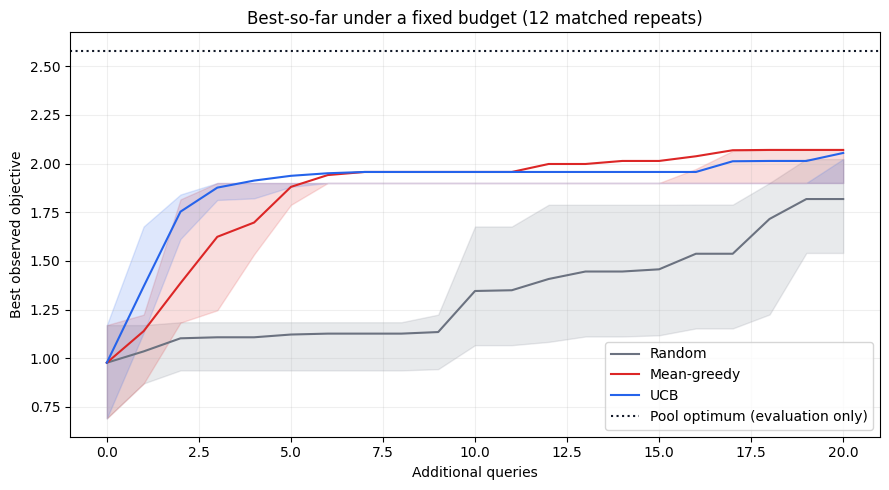

In [6]:
colors = {"random": "#6b7280", "greedy": "#dc2626", "ucb": "#2563eb"}
labels = {"random": "Random", "greedy": "Mean-greedy", "ucb": "UCB"}
steps = np.arange(QUERY_BUDGET + 1)

fig, ax = plt.subplots(figsize=(9, 5))
for strategy in strategy_names:
    values = histories[strategy]
    mean = values.mean(axis=0)
    lower = np.quantile(values, 0.25, axis=0)
    upper = np.quantile(values, 0.75, axis=0)
    ax.plot(steps, mean, label=labels[strategy], color=colors[strategy])
    ax.fill_between(steps, lower, upper, color=colors[strategy], alpha=0.15)

ax.axhline(global_best, color="#111827", linestyle=":", label="Pool optimum (evaluation only)")
ax.set_title(f"Best-so-far under a fixed budget ({N_REPEATS} matched repeats)")
ax.set_xlabel("Additional queries")
ax.set_ylabel("Best observed objective")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 6. Inspect one run in candidate space

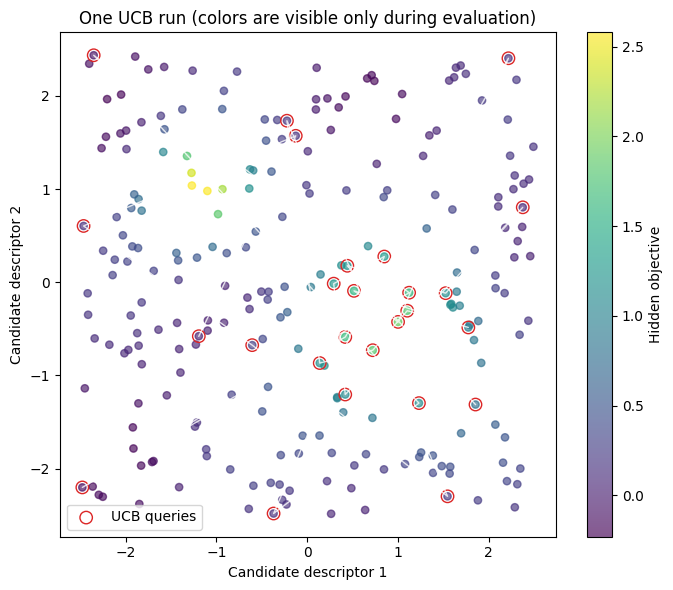

In [7]:
example_history, example_selected, example_trace = run_strategy("ucb", BASE_SEED)
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    candidates[:, 0], candidates[:, 1], c=true_values, cmap="viridis", s=28, alpha=0.65
)
ax.plot(
    candidates[example_selected, 0], candidates[example_selected, 1],
    color="white", linewidth=1.0, alpha=0.8
)
ax.scatter(
    candidates[example_selected, 0], candidates[example_selected, 1],
    facecolors="none", edgecolors="#dc2626", s=80, label="UCB queries"
)
ax.set_title("One UCB run (colors are visible only during evaluation)")
ax.set_xlabel("Candidate descriptor 1")
ax.set_ylabel("Candidate descriptor 2")
ax.legend()
fig.colorbar(scatter, ax=ax, label="Hidden objective")
plt.tight_layout()
plt.show()

## Checks

- 每次运行不重复查询候选；
- 三种策略使用相同初始样本、总预算和候选池；
- best-so-far 轨迹只能不降；
- 全局最优标签只用于事后评价，不能泄漏给选择策略；
- 图中阴影是重复运行的四分位区间，不是不确定性的通用置信区间。

In [8]:
for strategy, values in histories.items():
    assert values.shape == (N_REPEATS, QUERY_BUDGET + 1)
    assert np.all(np.diff(values, axis=1) >= -1e-12)
    assert np.all(values <= global_best + 1e-12)
assert list(decision_trace.columns) == trace_columns
expected_trace_rows = len(strategy_names) * N_REPEATS * (INITIAL_SAMPLES + QUERY_BUDGET)
assert len(decision_trace) == expected_trace_rows
assert decision_trace.groupby(["strategy", "repeat"])["candidate_id"].nunique().eq(
    INITIAL_SAMPLES + QUERY_BUDGET
).all()
assert decision_trace.loc[decision_trace["phase"] == "query", "query_step"].between(
    1, QUERY_BUDGET
).all()
assert decision_trace["failure_status"].eq("ok").all()
summary_lookup = summary.set_index("strategy")
print(
    "RESULT_CONTRACT screening "
    f"random_mean_final_best={summary_lookup.loc['random', 'mean_final_best']:.6f} "
    f"greedy_mean_final_best={summary_lookup.loc['greedy', 'mean_final_best']:.6f} "
    f"ucb_mean_final_best={summary_lookup.loc['ucb', 'mean_final_best']:.6f} "
    f"random_success_95pct={summary_lookup.loc['random', 'success_within_95pct_of_pool_best']:.6f} "
    f"greedy_success_95pct={summary_lookup.loc['greedy', 'success_within_95pct_of_pool_best']:.6f} "
    f"ucb_success_95pct={summary_lookup.loc['ucb', 'success_within_95pct_of_pool_best']:.6f}"
)
print("CONTRACT screening: strategies=3 repeats=12 budget=20 ledger_schema=12 unique_queries=yes")
print("预算、唯一查询、轨迹单调性、上界和审计账本检查通过。")

RESULT_CONTRACT screening random_mean_final_best=1.817893 greedy_mean_final_best=2.070244 ucb_mean_final_best=2.054601 random_success_95pct=0.166667 greedy_success_95pct=0.250000 ucb_success_95pct=0.166667
CONTRACT screening: strategies=3 repeats=12 budget=20 ledger_schema=12 unique_queries=yes
预算、唯一查询、轨迹单调性、上界和审计账本检查通过。


## Next Steps

1. 改变探索系数，观察 UCB 的探索—利用权衡；
2. 加入查询成本和不可行候选，改写为约束优化；
3. 用校准较差的模型重复实验，观察不确定性误导决策的方式；
4. 在真实材料或反应数据上先明确“一个查询”代表计算、测量还是实验。

**结论边界：**某策略在本候选池上取得更高平均 best-so-far，只说明它在声明的模型、预算和目标下表现更好；不能推出它在所有科学优化问题中占优，更不能把找到高值候选直接称为科学发现。